In [6]:
# pull the cfb api key from the .env file
import os
from dotenv import load_dotenv, find_dotenv
import cfbd
import pandas as pd
import numpy as np

load_dotenv(find_dotenv())  # go up one directory

CFB_API_KEY = os.getenv('CFBD_API_KEY')

In [7]:
import cfbd
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

configuration = cfbd.Configuration()
configuration.access_token = os.environ["CFBD_API_KEY"]

api_client = cfbd.ApiClient(configuration)
players_api = cfbd.PlayersApi(api_client)
stats_api = cfbd.StatsApi(api_client)

results = players_api.search_players(search_term="Bryce Young")
usage = players_api.get_player_usage(year=2024, team="Alabama")
stats = stats_api.get_player_season_stats(year=2024, team="Alabama")
returning = players_api.get_returning_production(year=2024, team="Alabama")
transfers = players_api.get_transfer_portal(year=2024)

In [8]:
import cfbd
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

configuration = cfbd.Configuration()
configuration.access_token = os.environ["CFBD_API_KEY"]

api_client = cfbd.ApiClient(configuration)
players_api = cfbd.PlayersApi(api_client)
stats_api = cfbd.StatsApi(api_client)

results = players_api.search_players(search_term="Bryce Young")
usage = players_api.get_player_usage(year=2024, team="Alabama")
stats = stats_api.get_player_season_stats(year=2024, team="Alabama")
returning = players_api.get_returning_production(year=2024, team="Alabama")
transfers = players_api.get_transfer_portal(year=2024)

print(results)
print(usage)
print(stats)

[PlayerSearchResult(id='4685720', team='Alabama', name='Bryce Young', first_name='Bryce', last_name='Young', weight=194, height=72, jersey=9, position='QB', hometown='Pasadena', team_color='#9e1632', team_color_secondary='#ffffff'), PlayerSearchResult(id='5112630', team='Notre Dame', name='Bryce Young', first_name='Bryce', last_name='Young', weight=273, height=79, jersey=95, position='DL', hometown='Charlotte', team_color='#0c2340', team_color_secondary='#c99700')]
[PlayerUsage(season=2024, id='4432734', name='Jalen Milroe', position='QB', team='Alabama', conference='SEC', usage=PlayerUsageUsage(passing_downs=0.781, standard_downs=0.501, third_down=0.756, second_down=0.558, first_down=0.517, rush=0.318, var_pass=0.902, overall=0.578)), PlayerUsage(season=2024, id='4596545', name='C.J. Dippre', position='TE', team='Alabama', conference='SEC', usage=PlayerUsageUsage(passing_downs=0.045, standard_downs=0.034, third_down=0.029, second_down=0.021, first_down=0.053, rush=0.002, var_pass=0.08

In [9]:
# Bryce Young's last college season was 2022 (drafted by Panthers in 2023)
BRYCE_YOUNG_ID = '4685720'

raw = stats_api.get_player_season_stats(year=2022, team='Alabama')
bryce_stats = [s for s in raw if s.player_id == BRYCE_YOUNG_ID]

df = pd.DataFrame([{
    'category': s.category,
    'stat_type': s.stat_type,
    'stat': s.stat
} for s in bryce_stats])

df.pivot(index='category', columns='stat_type', values='stat')

stat_type,ATT,CAR,COMPLETIONS,FUM,INT,LONG,LOST,PCT,REC,TD,YDS,YPA,YPC
category,,,,,,,,,,,,,
fumbles,NaN,NaN,NaN,1,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN
passing,380,NaN,245,NaN,5,NaN,NaN,0.645,NaN,32,3328,8.8,NaN
rushing,NaN,49,NaN,NaN,NaN,63,NaN,NaN,NaN,4,185,NaN,3.8


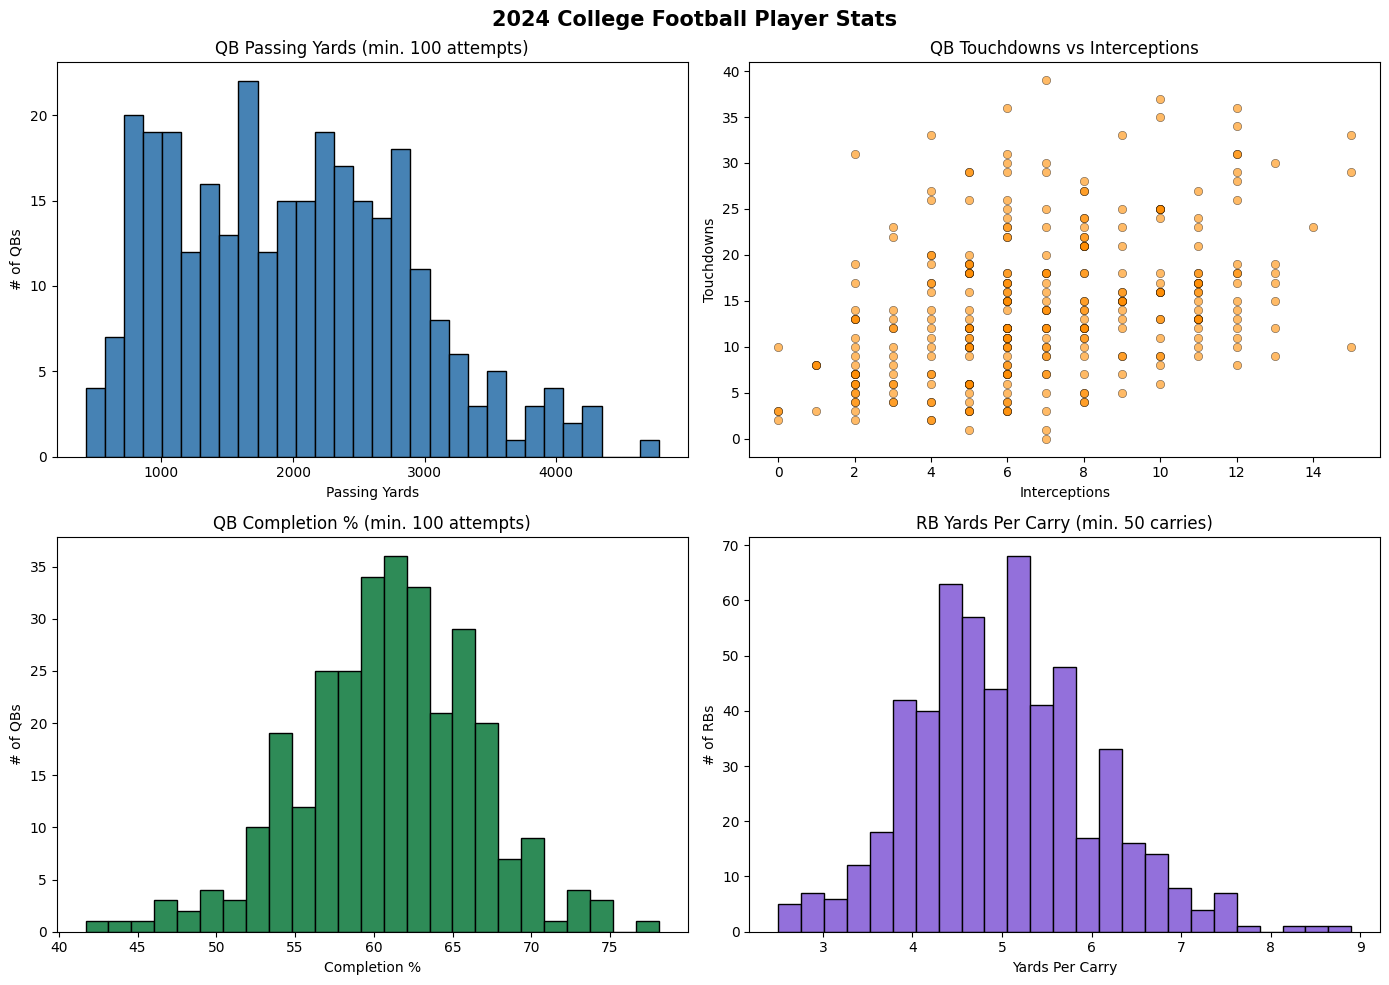

In [10]:
import matplotlib.pyplot as plt

# Fetch 2024 passing and rushing stats across all teams
passing_raw = stats_api.get_player_season_stats(year=2024, category='passing')
rushing_raw = stats_api.get_player_season_stats(year=2024, category='rushing')

def stats_to_wide(stats_list):
    records = [{
        'player': s.player, 'player_id': s.player_id,
        'position': s.position, 'team': s.team,
        'conference': s.conference, 'stat_type': s.stat_type,
        'stat': float(s.stat)
    } for s in stats_list]
    df = pd.DataFrame(records)
    return df.pivot_table(
        index=['player', 'player_id', 'position', 'team', 'conference'],
        columns='stat_type', values='stat'
    ).reset_index()

pass_df = stats_to_wide(passing_raw)
rush_df = stats_to_wide(rushing_raw)

# Filter to meaningful sample sizes
qbs = pass_df[pass_df['ATT'] >= 100].copy()
rbs = rush_df[(rush_df['position'] == 'RB') & (rush_df['CAR'] >= 50)].copy()

# PCT is stored as decimal (0.0–1.0)
qbs['COMP_PCT'] = qbs['PCT'] * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2024 College Football Player Stats', fontsize=15, fontweight='bold')

# QB passing yards distribution
axes[0, 0].hist(qbs['YDS'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('QB Passing Yards (min. 100 attempts)')
axes[0, 0].set_xlabel('Passing Yards')
axes[0, 0].set_ylabel('# of QBs')

# QB TD vs INT scatter
axes[0, 1].scatter(qbs['INT'], qbs['TD'], alpha=0.6, color='darkorange', edgecolors='black', linewidths=0.4)
axes[0, 1].set_title('QB Touchdowns vs Interceptions')
axes[0, 1].set_xlabel('Interceptions')
axes[0, 1].set_ylabel('Touchdowns')

# QB completion % distribution
axes[1, 0].hist(qbs['COMP_PCT'], bins=25, color='seagreen', edgecolor='black')
axes[1, 0].set_title('QB Completion % (min. 100 attempts)')
axes[1, 0].set_xlabel('Completion %')
axes[1, 0].set_ylabel('# of QBs')

# RB yards per carry distribution
axes[1, 1].hist(rbs['YPC'], bins=25, color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('RB Yards Per Carry (min. 50 carries)')
axes[1, 1].set_xlabel('Yards Per Carry')
axes[1, 1].set_ylabel('# of RBs')

plt.tight_layout()
plt.show()

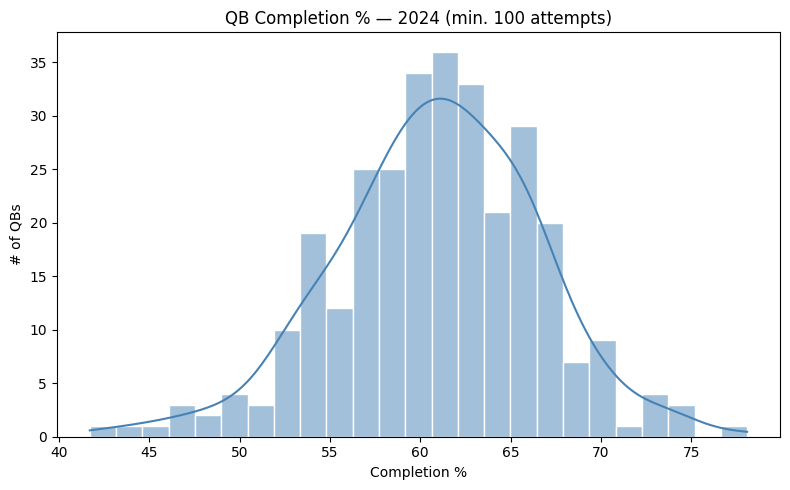

In [13]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(qbs['COMP_PCT'], bins=25, kde=True, color='steelblue', ax=ax, edgecolor='white' )
ax.set_title('QB Completion % — 2024 (min. 100 attempts)')
ax.set_xlabel('Completion %')
ax.set_ylabel('# of QBs')
plt.tight_layout()
plt.show()